In [1]:
# %% [markdown]
# # 02 - Feature Engineering
# ## Creating technical indicators and features

# %%
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import ta
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands
from src import utils, config

# %%
# Load cleaned data
df = pd.read_csv(config.CLEAN_DATA_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
print(f"Data shape: {df.shape}")

# %%
# Create target variable
df = utils.create_target(df, horizon=config.HORIZON, threshold=config.THRESHOLD)
print(f"Target distribution:\n{df['target'].value_counts(normalize=True)}")

# %%
# Feature engineering

# 1. Lagged returns
for lag in [1, 2, 4, 8, 24]:
    df[f'return_lag_{lag}'] = df['Close'].pct_change(lag)

# 2. Rolling volatility
df['volatility_24h'] = df['Close'].pct_change().rolling(24).std()

# 3. RSI
df['rsi'] = RSIIndicator(df['Close'], window=14).rsi()

# 4. MACD
macd = MACD(df['Close'])
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()

# 5. Bollinger Bands
bb = BollingerBands(df['Close'], window=20)
df['bb_high'] = bb.bollinger_hband()
df['bb_low'] = bb.bollinger_lband()
df['bb_position'] = (df['Close'] - df['bb_low']) / (df['bb_high'] - df['bb_low'])

# 6. Volume features
df['volume_ratio'] = df['Volume'] / df['Volume'].rolling(24).mean()

# 7. Price range
df['range'] = (df['High'] - df['Low']) / df['Close']

# %%
# Check for NaN values
print(f"NaN values after feature engineering:\n{df[config.FEATURES].isnull().sum()}")

# Drop NaN values
df = df.dropna()
print(f"Final shape after dropping NaN: {df.shape}")

# %%
# Save features data
df.to_csv(config.FEATURES_DATA_PATH, index=False)
print(f"Features saved to {config.FEATURES_DATA_PATH}")

Data shape: (17350, 7)
Target distribution:
target
0    0.622103
1    0.377897
Name: proportion, dtype: float64
NaN values after feature engineering:
return_lag_1       1
return_lag_2       2
return_lag_4       4
return_lag_8       8
return_lag_24     24
volatility_24h    24
rsi               13
macd              25
macd_signal       33
bb_high           19
bb_low            19
bb_position       19
volume_ratio      23
range              0
dtype: int64
Final shape after dropping NaN: (17313, 23)
Features saved to data/processed/btc_features.csv


target
0    0.622249
1    0.377751
Name: proportion, dtype: float64


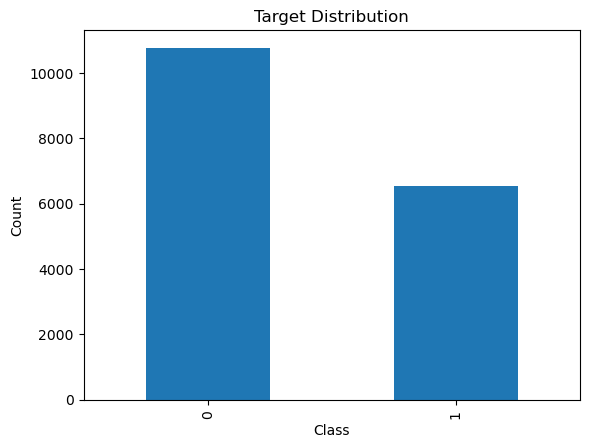

In [2]:
import matplotlib.pyplot as plt
print(df['target'].value_counts(normalize=True))

df['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


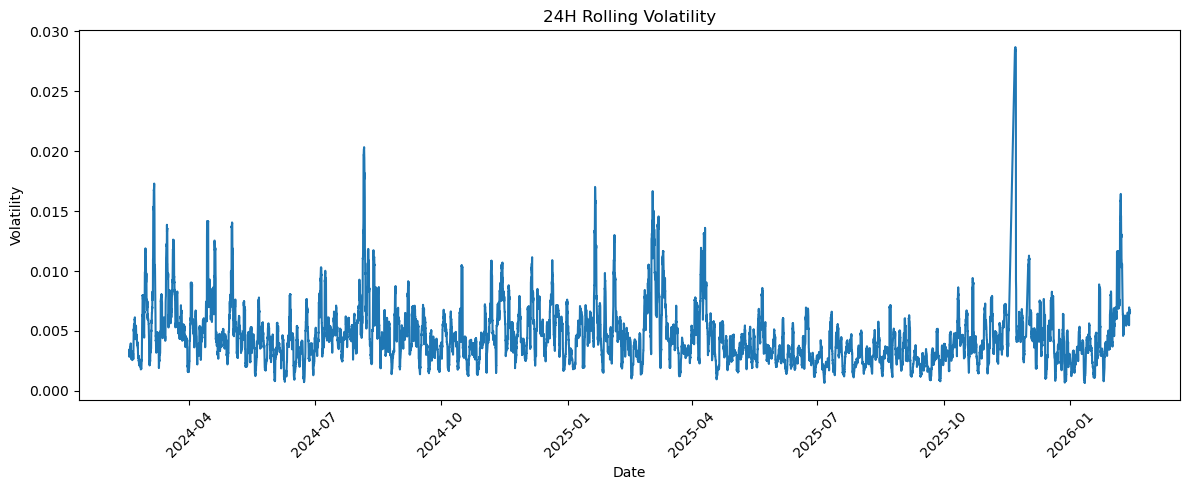

In [3]:
#
df['rolling_vol'] = df['returns'].rolling(24).std()

plt.figure(figsize=(12,5))
plt.plot(df['Datetime'], df['rolling_vol'])
plt.title('24H Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
